# Online linear regression using Kalman filtering

*This example is adapted from the [dynamax notebook of the same name](https://probml.github.io/dynamax/notebooks/linear_gaussian_ssm/kf_linreg.html).*

We perform sequential (recursive) Bayesian inference for the parameters of a linear regression model
using the Kalman filter. (This algorithm is also known as recursive least squares.)
To do this, we treat the parameters of the model as the unknown hidden states.
We assume that these are constant over time.

The model has the following form

\begin{align*}
\theta_t &=  \theta_{t-1}  \\
y_t &= x_t^T \theta_t + r_t, \; r_t \sim \mathcal{N}(0, \sigma^2)
\end{align*}

This is a special case of LG-SSM with _time-varying_ emission weights,
\begin{align*}
z_t &\sim \mathcal{N}(F z_{t-1}, Q) \\
y_t &\sim \mathcal{N}(H_t z_t, R)
\end{align*}
where the online parameter estimate $\theta_t$ corresponds to the latent state, $z_t$, the dynamics are deterministic ($F=I$, $Q=0$), the emission weights at time $t$ are the covariates $H_t = x_t^T$, and the emission covariance is $R = \sigma^2$.

## Setup

In [1]:
import numpyro.distributions as dist
from jax import numpy as jnp
from jax import vmap
from matplotlib import pyplot as plt

import dynestyx as dsx
from dynestyx import DynamicalModel
from dynestyx.inference.filters import Filter, KFConfig
from dynestyx.inference.integrations.utils import covariance_from_cholesky
from dynestyx.models import LinearGaussianObservation, LinearGaussianStateEvolution

## Data

Data is from [`linregOnlineDemoKalman.m`](https://github.com/probml/pmtk3/blob/master/demos/linregOnlineDemoKalman.m) in [pmtk3](https://github.com/probml/pmtk3).

In [2]:
n_obs = 21
x = jnp.linspace(0, 20, n_obs)
X = jnp.column_stack((jnp.ones_like(x), x))  # Design matrix.
y = jnp.array(
    [
        2.486,
        -0.303,
        -4.053,
        -4.336,
        -6.174,
        -5.604,
        -3.507,
        -2.326,
        -4.638,
        -0.233,
        -1.986,
        1.028,
        -2.264,
        -0.451,
        1.167,
        6.652,
        4.145,
        5.268,
        6.34,
        9.626,
        14.784,
    ]
)

## Model

In [3]:
F = jnp.eye(2)
# The weights are static (no parameter drift), so dynamically Q = 0. cuthbert's
# Kalman filter needs a positive-definite process covariance, so we use a tiny
# jitter in place of an exactly-zero Q.
Q = jnp.eye(2) * 1e-9
obs_var = 1.0
R = jnp.ones((1, 1)) * obs_var
mu0 = jnp.zeros(2)
Sigma0 = jnp.eye(2) * 10.0

# The covariates are encoded into a time-varying emission matrix H(t) = x_t^T,
# passed as a callable to LinearGaussianObservation.
obs_times = jnp.arange(float(n_obs))


def H(t):
    return X[jnp.asarray(t).astype(int)][None, :]  # (1, state_dim)


lgssm = DynamicalModel(
    initial_condition=dist.MultivariateNormal(mu0, Sigma0),
    state_evolution=LinearGaussianStateEvolution(A=F, cov=Q),
    observation_model=LinearGaussianObservation(H=H, R=R),
)

## Online inference

Now use the Kalman filter to estimate the filtering distributions, which correspond to the online estimate of the weights after each data point is observed.

In [4]:
with Filter(
    filter_config=KFConfig(
        filter_source="cuthbert",
        record_filtered_states_mean=True,
        record_filtered_states_cov=True,
    )
):
    lgssm_posterior = dsx.condition(
        "lgssm", lgssm, obs_times=obs_times, obs_values=y[:, None]
    )

online_mean = lgssm_posterior.states.mean  # (T, 2)
online_cov = covariance_from_cholesky(lgssm_posterior.states.chol_cov)  # (T, 2, 2)

## Offline inference

For comparison, we compute the offline posterior given all the data using Bayes rule for linear regression.
This should give the same results as the final step of online inference.

In [5]:
posterior_prec = jnp.linalg.inv(Sigma0) + X.T @ X / obs_var
offline_mean = jnp.linalg.solve(
    posterior_prec, jnp.linalg.inv(Sigma0) @ mu0 + X.T @ y / obs_var
)
offline_cov = jnp.linalg.inv(posterior_prec)

## Plot results

Finally, plot the online estimates of the linear regression weights and the offline estimates to which they converge. The shading represents the posterior standard deviation of the weights from the offline estimate.

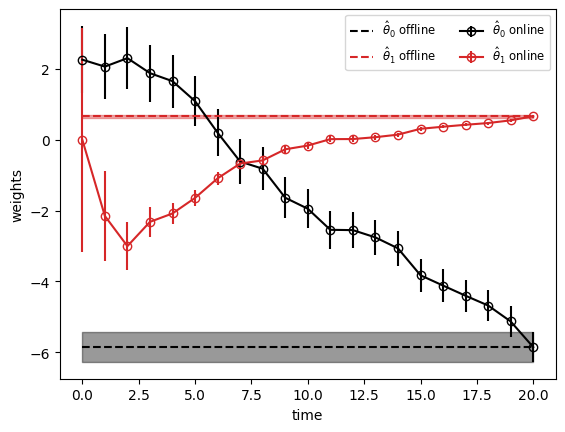

In [6]:
online_std = jnp.sqrt(vmap(jnp.diag)(online_cov))  # (T, 2)
offline_std = jnp.sqrt(jnp.diag(offline_cov))  # (2,)
timesteps = jnp.arange(n_obs)

fig, ax = plt.subplots()
for k, color in enumerate(["black", "tab:red"]):
    # Online Kalman filter estimate, with error bars.
    ax.errorbar(
        timesteps,
        online_mean[:, k],
        online_std[:, k],
        fmt="-o",
        color=color,
        fillstyle="none",
        label=rf"$\hat{{\theta}}_{k}$ online",
    )
    # Offline posterior mean and standard deviation for comparison.
    ax.hlines(
        offline_mean[k],
        timesteps[0],
        timesteps[-1],
        color=color,
        linestyle="--",
        label=rf"$\hat{{\theta}}_{k}$ offline",
    )
    ax.fill_between(
        timesteps,
        offline_mean[k] - offline_std[k],
        offline_mean[k] + offline_std[k],
        color=color,
        alpha=0.4,
    )

ax.set_xlabel("time")
ax.set_ylabel("weights")
ax.legend(loc="upper right", ncol=2, fontsize="small")
plt.show()